# Global Trends Analysis Using Gapminder DataSet 

# Problem Statement: 


The modern world is shaped by complex dynamics in population, health, and economics, making understanding these trends vital for informed policy-making. GlobalTrends, a leading analytics firm, is dedicated to deciphering these patterns through a comprehensive analysis of the Gapminder dataset. Your role in this project is to conduct an in-depth Exploratory Data Analysis (EDA), uncovering the intricate relationships between demographic changes, economic development, and health advancements over recent decades.


# 1.Import required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


#settings
plt.rcParams['figure.figsize'] =(10,5.5)
sns.set_style("whitegrid")


# 1.Load the dataset and display the first few rows. 


In [5]:
df = pd.read_csv("gapminder_full.csv")

In [6]:
df.head()

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710
3,Afghanistan,1967,11537966,Asia,34.020,836.197138
4,Afghanistan,1972,13079460,Asia,36.088,739.981106


In [7]:
df.tail()

,country,year,population,continent,life_exp,gdp_cap
1699,Zimbabwe,1987,9216418,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563,Africa,39.989,672.038623
1703,Zimbabwe,2007,12311143,Africa,43.487,469.709298


In [10]:
df.shape

(1704, 6)

# How many countries does the dataset have?

In [13]:
n_countries=df['country'].nunique()
print("Total countrries:",n_countries)

Total countrries: 142


# 2.Create a pivot table that shows the average life expectancy for each continent and year. Index by 'continent', use 'year' as columns, and 'life_exp' as values.


In [14]:
pivot_life =pd.pivot_table(
df,index='continent',columns='year',values='life_exp',aggfunc='mean')

In [15]:
pivot_life

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.135500,41.266346,43.319442,45.334538,47.450942,49.580423,51.592865,53.344788,53.629577,53.598269,53.325231,54.806038
Americas,53.279840,55.960280,58.398760,60.410920,62.394920,64.391560,66.228840,68.090720,69.568360,71.150480,72.422040,73.608120
Asia,46.314394,49.318544,51.563223,54.663640,57.319269,59.610556,62.617939,64.851182,66.537212,68.020515,69.233879,70.728485
Europe,64.408500,66.703067,68.539233,69.737600,70.775033,71.937767,72.806400,73.642167,74.440100,75.505167,76.700600,77.648600
Oceania,69.255000,70.295000,71.085000,71.310000,71.910000,72.855000,74.290000,75.320000,76.945000,78.190000,79.740000,80.719500


# 3. Which countries had a GDP per capita higher than the 75th percentile in 2007?

In [16]:
df_2007 = df[df['year']==2007]

q75 = df_2007['gdp_cap'].quantile(0.75)

high_gdp = df_2007[df_2007['gdp_cap'] > q75]['country']

print(high_gdp.tolist())

['Australia', 'Austria', 'Bahrain', 'Belgium', 'Canada', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong, China', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea, Rep.', 'Kuwait', 'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Portugal', 'Puerto Rico', 'Saudi Arabia', 'Singapore', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'United Kingdom', 'United States']


# 4.Categorize the 'life_exp' into 4 equally ranged bins from 'Low' to 'Very High'. Use cut to create these categorical life expectancy groups and add them as a new column 'Life_Exp_Range'.


In [17]:
df['Life_Exp_Range'] = pd.cut(
    df['life_exp'],
    bins=4,
    labels=['Low','Medium','High','Very High']
)

df[['life_exp','Life_Exp_Range']].head()

,life_exp,Life_Exp_Range
0,28.801,Low
1,30.332,Low
2,31.997,Low
3,34.020,Low
4,36.088,Low


# 5. Identify the top 5 countries with the highest GDP per capita in 2007. Use a horizontal bar chart to display this data.


            country      gdp_cap
1151         Norway  49357.19017
863          Kuwait  47306.98978
1367      Singapore  47143.17964
1619  United States  42951.65309
755         Ireland  40675.99635


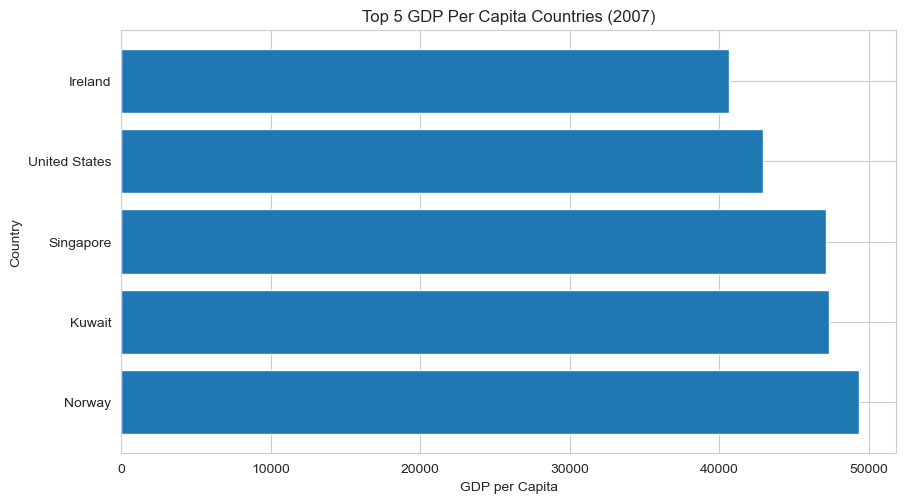

In [19]:
Top5 = df_2007.nlargest(5, 'gdp_cap')
print(Top5[['country','gdp_cap']])

plt.barh(Top5['country'], Top5['gdp_cap'])
plt.xlabel("GDP per Capita")
plt.ylabel("Country")
plt.title("Top 5 GDP Per Capita Countries (2007)")
plt.show()

# 6.Find all country names that start with "I" and end with "a" using regex.


In [20]:
pattern = r"^I.*a$"

matches = df['country'].unique()

result = [c for c in matches if re.match(pattern, c)]

print(result)

['India', 'Indonesia']


# 7.Create a boxplot using Seaborn to compare the distribution of GDP per capita for each continent in 2007.


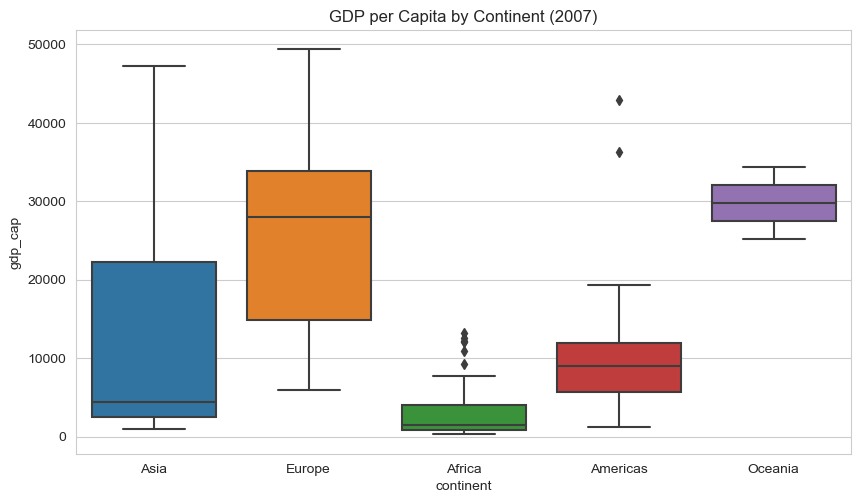

In [21]:
sns.boxplot(data=df_2007,
            x='continent',
            y='gdp_cap')

plt.title("GDP per Capita by Continent (2007)")
plt.show()

# 8.Find all countries with a life expectancy of over 80 years in 2007. List these countries and their respective continents.

In [22]:
life80 = df_2007[df_2007['life_exp'] > 80][['country','continent']]

print(life80)

               country continent
71           Australia   Oceania
251             Canada  Americas
539             France    Europe
671   Hong Kong, China      Asia
695            Iceland    Europe
767             Israel      Asia
779              Italy    Europe
803              Japan      Asia
1103       New Zealand   Oceania
1151            Norway    Europe
1427             Spain    Europe
1475            Sweden    Europe
1487       Switzerland    Europe


# 9.Convert the 'year' column to a datetime type and extract the decade. Create a new column 'Decade' that groups the years into decades (e.g., the 1950s, 1960s).


In [23]:
df['year_dt'] = pd.to_datetime(df['year'], format='%Y')

df['Decade'] = (df['year']//10)*10

df[['year','Decade']].head()

,year,Decade
0,1952,1950
1,1957,1950
2,1962,1960
3,1967,1960
4,1972,1970


# 10.Compute the correlation matrix between GDP per capita, life expectancy, and population for the dataset. Then, use Seaborn to visualize this correlation matrix as a heatmap.


In [24]:
corr = df[['gdp_cap','life_exp','population']].corr()

print(corr)

             gdp_cap  life_exp  population
gdp_cap     1.000000  0.583706   -0.025600
life_exp    0.583706  1.000000    0.064955
population -0.025600  0.064955    1.000000


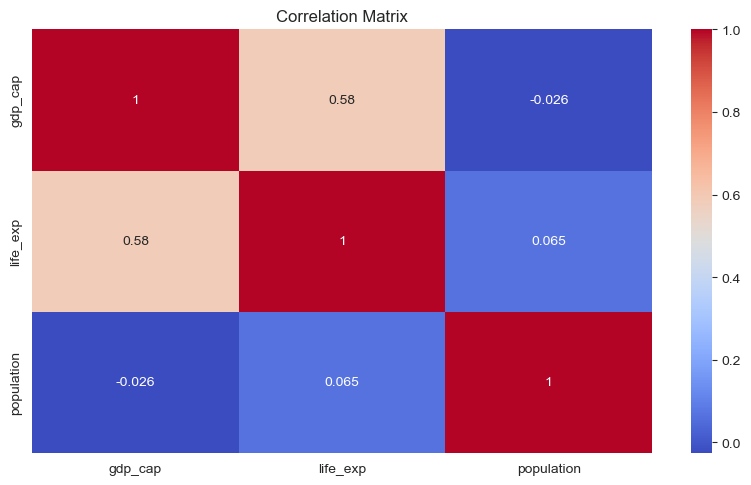

In [25]:
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

# 11.How has the global average life expectancy changed from 1952 to 2007? Plot a line graph to visualize this trend.


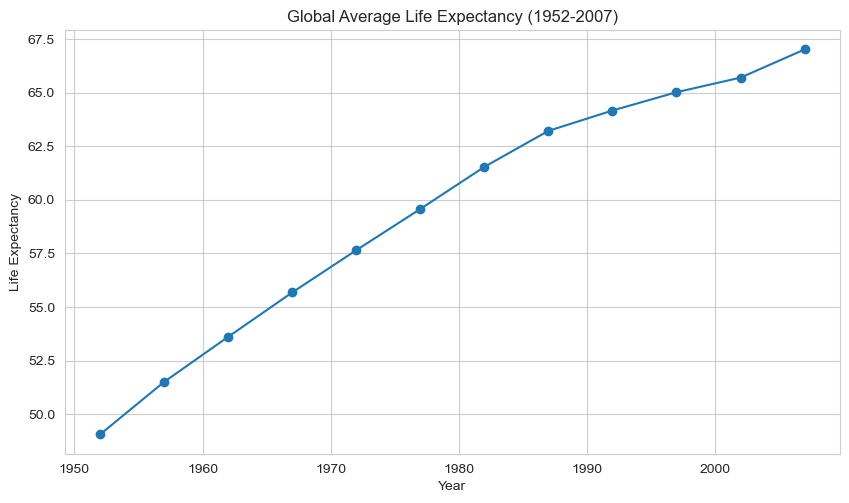

In [26]:
life_trend = df.groupby('year')['life_exp'].mean()

plt.plot(life_trend.index,
         life_trend.values,
         marker='o')

plt.title("Global Average Life Expectancy (1952-2007)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

Subjective Question: Discuss the various reasons that could have contributed to the change.

Medical advancements — development of antibiotics, vaccines, and improved surgical treatments.
Better healthcare systems — wider access to hospitals, doctors, and preventive care.
Improved sanitation — cleaner water and better hygiene reduced infectious diseases.
Better nutrition — increased food availability and reduced malnutrition.


# 12.For the year 2007, analyze the relationship between life expectancy and GDP per capita. 

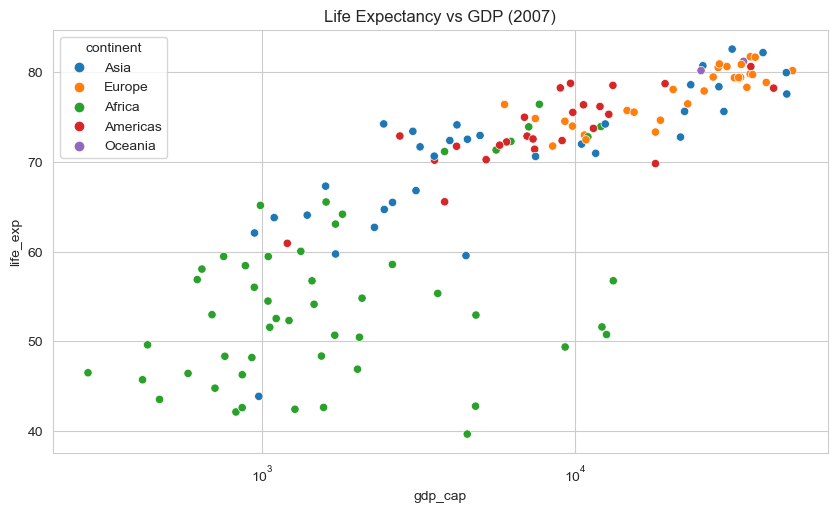

In [27]:
sns.scatterplot(data=df_2007,
                x='gdp_cap',
                y='life_exp',
                hue='continent')

plt.xscale('log')
plt.title("Life Expectancy vs GDP (2007)")
plt.show()

Subjective Question: Is there a noticeable trend or correlation? Represent this using a scatter plot.
1.richer countries usually live longer
2.after a threshold, gains flatten

# 13.Compare the average GDP per capita for each continent in the year 2007. Use a bar chart for this comparison.


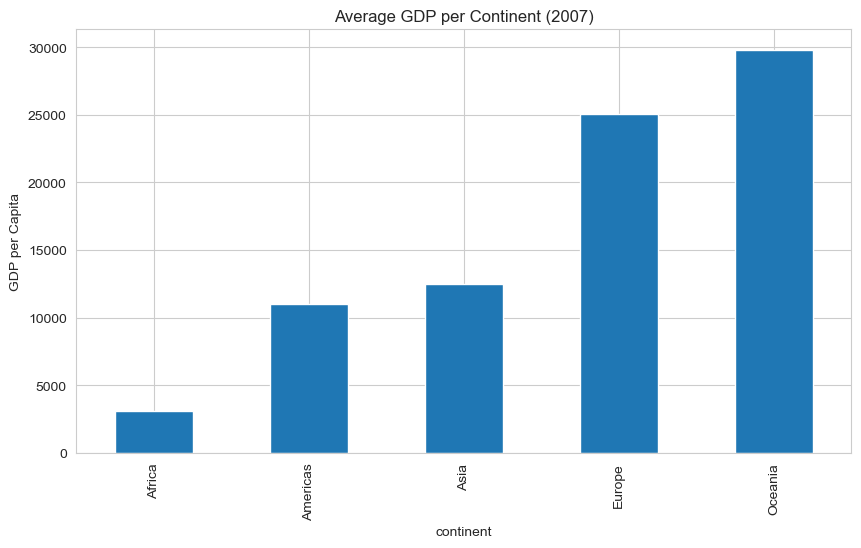

In [29]:
avg_gdp = df_2007.groupby('continent')['gdp_cap'].mean()

avg_gdp.plot(kind='bar')

plt.title("Average GDP per Continent (2007)")
plt.ylabel("GDP per Capita")
plt.show()

Subjective Quetion:  Why is the average GDP per capita for Oceania higher than the Americas even though the Americas have more countries?


only Australia and New Zealand
both highly developed
Americas includes many lower-income nations like Haiti and Bolivia, lowering average

# 14.Compare the life expectancy and GDP per capita of Afghanistan (a country known for its historical conflicts) and Switzerland (representing a peaceful and economically prosperous country) using the dataset provided.


In [30]:
compare = df[df['country'].isin(['Afghanistan','Switzerland'])]
compare_2007 = compare[compare['year']==2007]

# Firstly, for the year 2007, use a bar chart to directly compare the life expectancy and GDP per capita between these two countries.


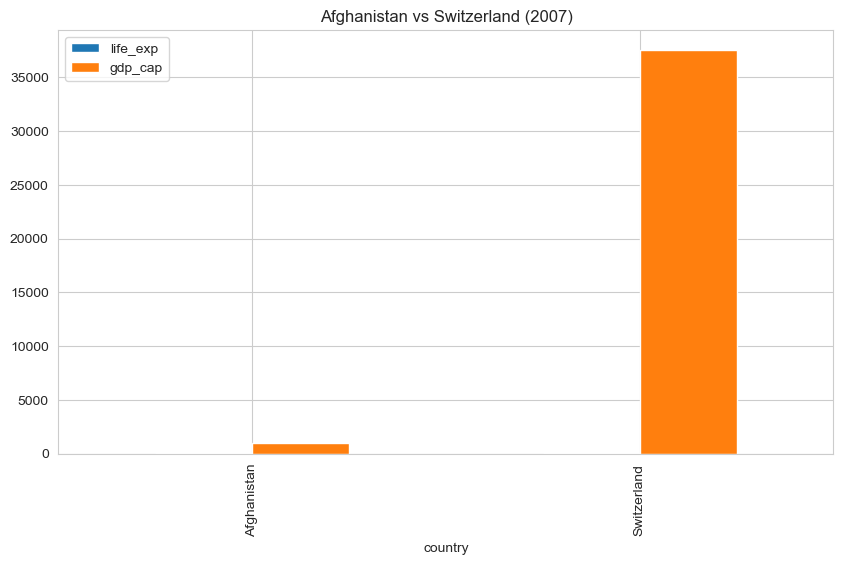

In [31]:
compare_2007.plot(
    x='country',
    y=['life_exp','gdp_cap'],
    kind='bar'
)

plt.title("Afghanistan vs Switzerland (2007)")
plt.show()

# Then, create two separate line graphs to show the trends of these two metrics over all available years in the dataset for both countries.


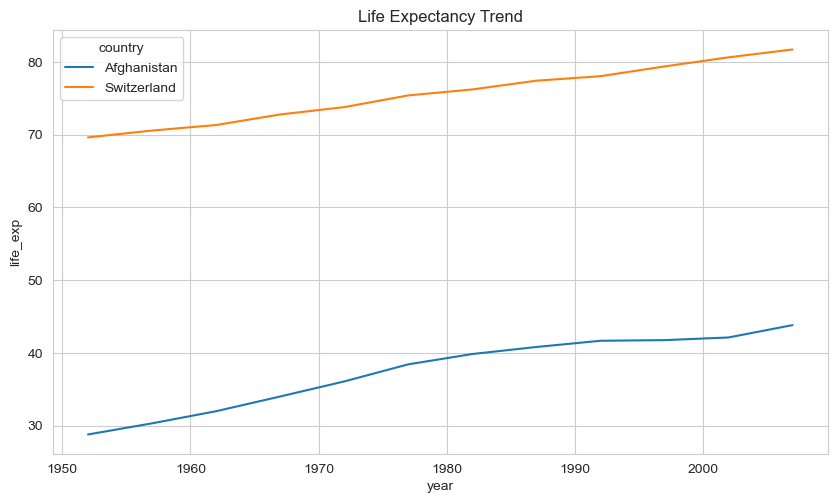

In [32]:
sns.lineplot(data=compare,
             x='year',
             y='life_exp',
             hue='country')

plt.title("Life Expectancy Trend")
plt.show()

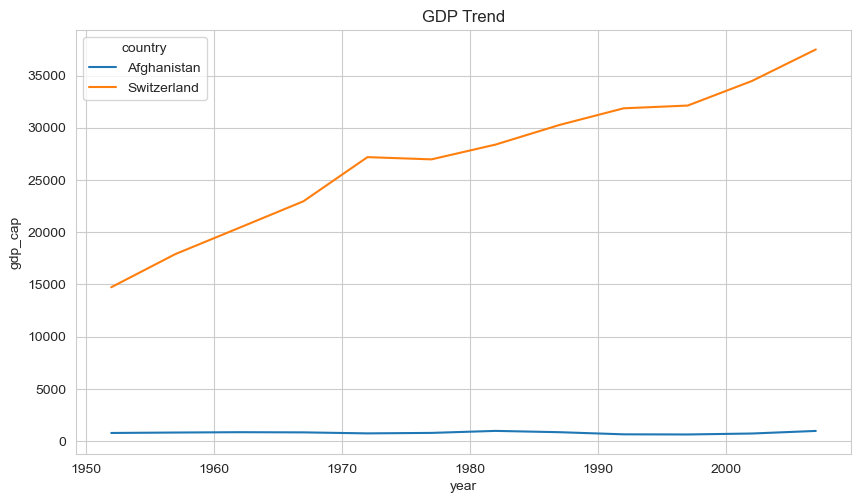

In [33]:
sns.lineplot(data=compare,
             x='year',
             y='gdp_cap',
             hue='country')

plt.title("GDP Trend")
plt.show()

Subjective Question: What differences do you observe in terms of life expectancy and economic development? How might the stability or instability of a country influence these key metrics over time? Analyze the data through these visualizations and discuss your inferences.


# Afghanistan
repeated conflicts,
political instability,
poor healthcare,
low GDP,
lower life expectancy
# Switzerland
political stability,
strong economy,
advanced healthcare,
high education,
long life expectancy,